In [35]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [36]:
df = pd.read_csv("online_classroom_data.csv")

print("Shape:", df.shape)
df.head()

Shape: (71, 16)


,Unnamed: 0,total_posts,helpful_post,nice_code_post,collaborative_post,confused_post,creative_post,bad_post,amazing_post,timeonline,sk1_classroom,sk2_classroom,sk5_classroom,sk3_classroom,sk4_classroom,Approved
0,0,1.0,0.0,0.0,0.0,0.0,6.0,0.0,1.0,1600.0,"2,1","2,4","3,5","3,6","1,7",0
1,1,1.0,0.0,0.0,1.0,0.0,2.0,0.0,3.0,592.0,"0,3","0,3",0,"0,1","0,2",0
2,2,2.0,4.0,3.0,9.0,0.0,16.0,1.0,8.0,1110.0,8,5,5,7,5,1
3,3,5.0,1.0,3.0,9.0,2.0,11.0,0.0,8.0,8651.0,6,5,4,6,4,1
4,4,14.0,6.0,15.0,28.0,0.0,50.0,0.0,45.0,34172.0,"8,7",9,"6,5",10,"8,8",1


In [37]:
# Drop useless column
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Fix comma decimals
problem_cols = [
    'sk1_classroom','sk2_classroom','sk3_classroom',
    'sk4_classroom','sk5_classroom'
]

for col in problem_cols:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna()

print(df.dtypes)

total_posts           float64
helpful_post          float64
nice_code_post        float64
collaborative_post    float64
confused_post         float64
creative_post         float64
bad_post              float64
amazing_post          float64
timeonline            float64
sk1_classroom         float64
sk2_classroom         float64
sk5_classroom         float64
sk3_classroom         float64
sk4_classroom         float64
Approved                int64
dtype: object


In [38]:
# Load original dataset
df = pd.read_csv("online_classroom_data.csv")

# Remove index column
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Fix classroom score columns
score_cols = [
    "sk1_classroom",
    "sk2_classroom",
    "sk3_classroom",
    "sk4_classroom",
    "sk5_classroom"
]

for col in score_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

# Generate synthetic data
n_new = 250

synthetic_rows = []

for _ in range(n_new):

    approved = np.random.choice(
        [0, 1],
        p=df["Approved"].value_counts(normalize=True).sort_index().values
    )

    if approved == 1:
        total_posts = np.random.randint(5, 40)
        helpful_post = np.random.randint(2, 25)
        nice_code_post = np.random.randint(2, 35)
        collaborative_post = np.random.randint(5, 50)
        creative_post = np.random.randint(5, 70)
        amazing_post = np.random.randint(5, 70)
        confused_post = np.random.randint(0, 2)
        bad_post = np.random.randint(0, 1)
        timeonline = np.random.randint(8000, 40000)

        scores = np.round(
            np.random.uniform(6.0, 10.0, 5),
            1
        )

    else:
        total_posts = np.random.randint(0, 8)
        helpful_post = np.random.randint(0, 5)
        nice_code_post = np.random.randint(0, 5)
        collaborative_post = np.random.randint(0, 10)
        creative_post = np.random.randint(0, 20)
        amazing_post = np.random.randint(0, 20)
        confused_post = np.random.randint(1, 7)
        bad_post = np.random.randint(0, 3)
        timeonline = np.random.randint(0, 10000)

        scores = np.round(
            np.random.uniform(0.0, 5.5, 5),
            1
        )

    synthetic_rows.append([
        total_posts,
        helpful_post,
        nice_code_post,
        collaborative_post,
        confused_post,
        creative_post,
        bad_post,
        amazing_post,
        timeonline,
        scores[0],
        scores[1],
        scores[2],
        scores[3],
        scores[4],
        approved
    ])

synthetic_df = pd.DataFrame(
    synthetic_rows,
    columns=[
        "total_posts",
        "helpful_post",
        "nice_code_post",
        "collaborative_post",
        "confused_post",
        "creative_post",
        "bad_post",
        "amazing_post",
        "timeonline",
        "sk1_classroom",
        "sk2_classroom",
        "sk3_classroom",
        "sk4_classroom",
        "sk5_classroom",
        "Approved"
    ]
)

# Combine
final_df = pd.concat([df, synthetic_df], ignore_index=True)

print("Original:", len(df))
print("Synthetic:", len(synthetic_df))
print("Final:", len(final_df))

final_df.to_csv("online_classroom_data_augmented.csv", index=False)

Original: 71
Synthetic: 250
Final: 321


In [39]:
target = "Approved"

X = df.drop(columns=[target])
y = df[target]

In [40]:
X["engagement_score"] = (
    X["helpful_post"] +
    X["nice_code_post"] +
    X["collaborative_post"]
) / 3

X["positive_behavior"] = X["creative_post"] + X["amazing_post"]
X["negative_behavior"] = X["bad_post"] + X["confused_post"]

X["activity_intensity"] = X["total_posts"] + X["timeonline"]
X["focus_ratio"] = X["helpful_post"] / (X["bad_post"] + 1)

# Save column order (IMPORTANT)
feature_columns = X.columns

X.head()

,total_posts,helpful_post,nice_code_post,collaborative_post,confused_post,creative_post,bad_post,amazing_post,timeonline,sk1_classroom,sk2_classroom,sk5_classroom,sk3_classroom,sk4_classroom,engagement_score,positive_behavior,negative_behavior,activity_intensity,focus_ratio
0,1.0,0.0,0.0,0.0,0.0,6.0,0.0,1.0,1600.0,2.1,2.4,3.5,3.6,1.7,0.000000,7.0,0.0,1601.0,0.0
1,1.0,0.0,0.0,1.0,0.0,2.0,0.0,3.0,592.0,0.3,0.3,0.0,0.1,0.2,0.333333,5.0,0.0,593.0,0.0
2,2.0,4.0,3.0,9.0,0.0,16.0,1.0,8.0,1110.0,8.0,5.0,5.0,7.0,5.0,5.333333,24.0,1.0,1112.0,2.0
3,5.0,1.0,3.0,9.0,2.0,11.0,0.0,8.0,8651.0,6.0,5.0,4.0,6.0,4.0,4.333333,19.0,2.0,8656.0,1.0
4,14.0,6.0,15.0,28.0,0.0,50.0,0.0,45.0,34172.0,8.7,9.0,6.5,10.0,8.8,16.333333,95.0,0.0,34186.0,6.0


In [41]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [42]:
rf_model = RandomForestClassifier(n_estimators=150, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:,1]

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_proba))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0


In [43]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:,1]

print("XGB Accuracy:", accuracy_score(y_test, xgb_pred))
print("XGB AUC:", roc_auc_score(y_test, xgb_proba))

XGB Accuracy: 1.0
XGB AUC: 1.0


In [44]:
rf_auc = roc_auc_score(y_test, rf_proba)
xgb_auc = roc_auc_score(y_test, xgb_proba)

best_model = rf_model if rf_auc > xgb_auc else xgb_model

comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, xgb_proba)
    ]
})

comparison

,Model,Accuracy,ROC_AUC
0,Random Forest,1.0,1.0
1,XGBoost,1.0,1.0


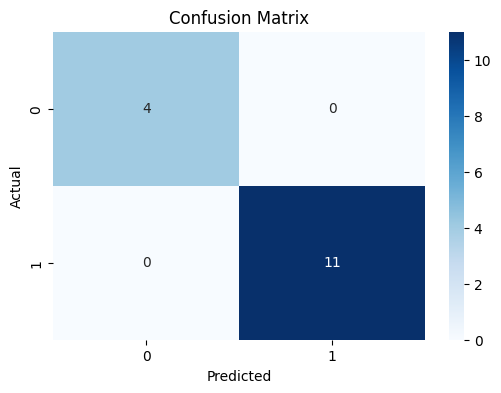

In [45]:
cm = confusion_matrix(y_test, best_model.predict(X_test))

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

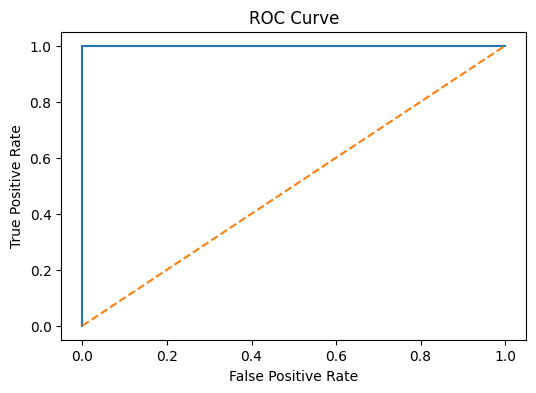

In [46]:
proba = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.savefig(
    "roc_curve.png",
    bbox_inches="tight"
)

plt.show()

In [47]:
if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({
        "Feature": feature_columns,
        "Importance": best_model.feature_importances_
    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    display(importance.head(10))

,Feature,Importance
9,sk1_classroom,1.0
10,sk2_classroom,0.0
17,activity_intensity,0.0
16,negative_behavior,0.0
15,positive_behavior,0.0
14,engagement_score,0.0
13,sk4_classroom,0.0
12,sk3_classroom,0.0
11,sk5_classroom,0.0
0,total_posts,0.0


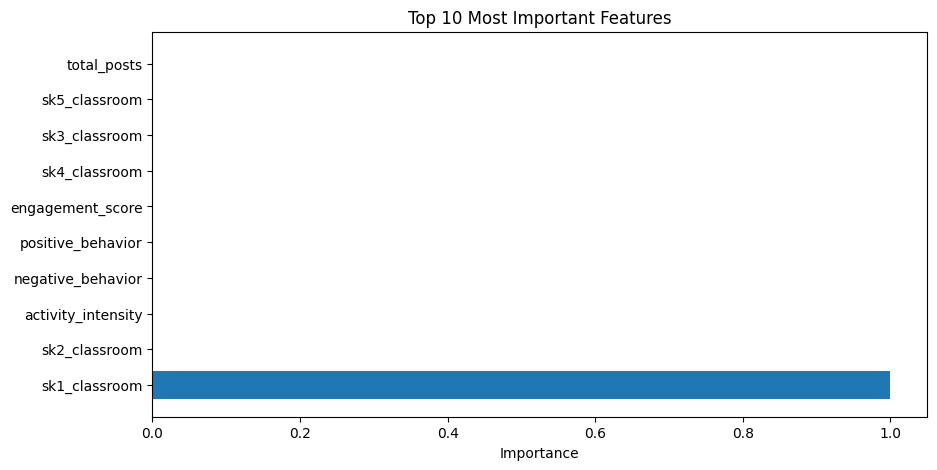

In [48]:
plt.figure(figsize=(10,5))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance")

plt.savefig(
    "feature_importance.png",
    bbox_inches="tight"
)

plt.show()

In [49]:
def recommendation(prob):

    if prob < 0.4:
        return """
        High Risk:
        - Increase participation
        - Spend more time online
        - Improve classroom performance
        """

    elif prob < 0.7:
        return """
        Medium Risk:
        - Increase engagement
        - Participate in discussions
        """

    else:
        return """
        Low Risk:
        - Keep up the good work
        """

In [50]:
# Save everything needed for deployment
joblib.dump(best_model, "student_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")  # 🔥 IMPORTANT

print("Model + scaler + feature_columns saved!")

Model + scaler + feature_columns saved!


In [51]:
# Example test input (change values)
sample = pd.DataFrame([{
    "helpful_post": 10,
    "nice_code_post": 8,
    "collaborative_post": 7,
    "creative_post": 5,
    "amazing_post": 6,
    "bad_post": 2,
    "confused_post": 3,
    "total_posts": 40,
    "timeonline": 20,
    "sk1_classroom": 3.5,
    "sk2_classroom": 3.8,
    "sk3_classroom": 4.0,
    "sk4_classroom": 3.7,
    "sk5_classroom": 3.9
}])

# Feature engineering
sample["engagement_score"] = (
    sample["helpful_post"] +
    sample["nice_code_post"] +
    sample["collaborative_post"]
) / 3

sample["positive_behavior"] = sample["creative_post"] + sample["amazing_post"]
sample["negative_behavior"] = sample["bad_post"] + sample["confused_post"]
sample["activity_intensity"] = sample["total_posts"] + sample["timeonline"]
sample["focus_ratio"] = sample["helpful_post"] / (sample["bad_post"] + 1)

# Match column order
sample = sample[feature_columns]

# Predict
scaled = scaler.transform(sample)
prob = best_model.predict_proba(scaled)[0][1]

print("Probability:", prob)
print(recommendation(prob))

Probability: 0.06076721

        High Risk:
        - Increase participation
        - Spend more time online
        - Improve classroom performance
        


In [52]:
app_code = """
# (paste the Streamlit code here from previous answer)
"""

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py created!")

app.py created!


In [53]:
req = """streamlit
pandas
numpy
scikit-learn
xgboost
joblib
"""

with open("requirements.txt", "w") as f:
    f.write(req)

print("requirements.txt created!")

requirements.txt created!
